In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import tensorflow as tf

print(nltk.__version__)
print(tf.__version__)


3.10.3
2.21.0


In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Huma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Huma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Huma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Huma\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Huma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Huma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perc

True

In [5]:
from nltk.tokenize import word_tokenize

In [6]:
text = "Don't be fooled by the sight of it."

tokens = word_tokenize(text)
print(tokens)

['Do', "n't", 'be', 'fooled', 'by', 'the', 'sight', 'of', 'it', '.']


In [7]:
from nltk.tokenize import sent_tokenize

In [8]:
text = """I love Natural Language Processing.
NLP is fascinating.
I am learning tokenization."""
sentences = sent_tokenize(text)
print(sentences)

['I love Natural Language Processing.', 'NLP is fascinating.', 'I am learning tokenization.']


In [9]:
text = """I love Natural Language Processing.
NLP is fascinating.
I am learning tokenization."""

sentences = sent_tokenize(text)

In [10]:
for sentence in sentences:
    tokens = word_tokenize(sentence)
    print(tokens)

['I', 'love', 'Natural', 'Language', 'Processing', '.']
['NLP', 'is', 'fascinating', '.']
['I', 'am', 'learning', 'tokenization', '.']


In [11]:
text = "Dr. Smith teaches Artificial Intelligence."

print(sent_tokenize(text))

['Dr. Smith teaches Artificial Intelligence.']


In [12]:
from tensorflow.keras.preprocessing.text import (
    text_to_word_sequence
)

In [13]:
text = "Don't be fooled by the sight of it."

tokens = text_to_word_sequence(text)
print(tokens)

["don't", 'be', 'fooled', 'by', 'the', 'sight', 'of', 'it']


In [14]:
from nltk.corpus import stopwords

In [15]:
stop_words = set(stopwords.words('english'))

len(stop_words)

198

In [16]:
print("the" in stop_words)
print("he" in stop_words)
print("is" in stop_words)
print("cat" in stop_words)
print("india" in stop_words)

True
True
True
False
False


In [17]:
text = "This movie is not good"

tokens = word_tokenize(text)

filtered_tokens = []

for word in tokens:
    if word.lower() not in stop_words:
        filtered_tokens.append(word)

print("Original: ",tokens)
print("After removing stop words: ")
print(filtered_tokens)

Original:  ['This', 'movie', 'is', 'not', 'good']
After removing stop words: 
['movie', 'good']


In [18]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [19]:
print(lemmatizer.lemmatize("studies"))

study


In [20]:
print(lemmatizer.lemmatize("plays"))

play


In [21]:
print(lemmatizer.lemmatize("playing",pos='v'))

play


In [22]:
words = [
    "policy","doing","organization","have","going","love",
    "lives","fly","dies","watched","has","starting"
]

for word in words:
    print(word, "->", lemmatizer.lemmatize(word),end=" | ")
    print(word, "->", lemmatizer.lemmatize(word,pos='v'))

policy -> policy | policy -> policy
doing -> doing | doing -> do
organization -> organization | organization -> organization
have -> have | have -> have
going -> going | going -> go
love -> love | love -> love
lives -> life | lives -> live
fly -> fly | fly -> fly
dies -> dy | dies -> die
watched -> watched | watched -> watch
has -> ha | has -> have
starting -> starting | starting -> start


In [23]:
words = [
    "running","is","are","was","were","being",
    "been","he","she","they","me","I"
]

for word in words:
    print(word, "->", lemmatizer.lemmatize(word,pos='v'))


running -> run
is -> be
are -> be
was -> be
were -> be
being -> be
been -> be
he -> he
she -> she
they -> they
me -> me
I -> I


In [24]:
#Lemmatize this sentence:
text = "The students are studying and playing games."
tokens = word_tokenize(text)

lemmas = []

for word in tokens:
    lemma = lemmatizer.lemmatize(word,pos='v')
    #POS
    lemmas.append(lemma)

print(tokens)
print(lemmas)

['The', 'students', 'are', 'studying', 'and', 'playing', 'games', '.']
['The', 'students', 'be', 'study', 'and', 'play', 'game', '.']


In [25]:
#Stemming -> NLTK -> PorterStemmer

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [26]:
words = ["playing", "played", "plays", "studies", "studying"]

for word in words:
    print(word,"->",stemmer.stem(word))

playing -> play
played -> play
plays -> play
studies -> studi
studying -> studi


In [27]:
#both stemming and lemmatization
words = ["studies", "studying", "studied", "study"]

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

for word in words:
    stem = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word)

    print(f"{word} -> stem: {stem} -> lemma: {lemma}")

studies -> stem: studi -> lemma: study
studying -> stem: studi -> lemma: studying
studied -> stem: studi -> lemma: studied
study -> stem: studi -> lemma: study


In [28]:
#PorterStemmer vs LancasterStemmer
#different algorithms can give different results

words = ['formalize','allowance','electrical']

print([stemmer.stem(w) for w in words])

['formal', 'allow', 'electr']


In [29]:
from nltk.stem import LancasterStemmer

lstemmer = LancasterStemmer()

words = [
    "policy","doing","organization","have","going","love",
    "lives","fly","dies","watched","has","starting",
    'formalize','allowance','electrical'
]
for w in words:
    print(stemmer.stem(w),"->",lstemmer.stem(w))

polici -> policy
do -> doing
organ -> org
have -> hav
go -> going
love -> lov
live -> liv
fli -> fly
die -> die
watch -> watch
ha -> has
start -> start
formal -> form
allow -> allow
electr -> elect


In [30]:

words = [
    "policy","doing","organization","have","going","love",
    "lives","fly","dies","watched","has","starting",
    'formalize','allowance','electrical'
]
for w in words:
    print(stemmer.stem(w))

polici
do
organ
have
go
love
live
fli
die
watch
ha
start
formal
allow
electr


In [31]:
text = [
    "playing","played","studies","studying","connection",
    "organization","organized"
]

for word in text:
    print(word," | ",lemmatizer.lemmatize(word)," | ",
          stemmer.stem(word)," | ",lstemmer.stem(word))

playing  |  playing  |  play  |  play
played  |  played  |  play  |  play
studies  |  study  |  studi  |  study
studying  |  studying  |  studi  |  study
connection  |  connection  |  connect  |  connect
organization  |  organization  |  organ  |  org
organized  |  organized  |  organ  |  org


"The cat is sleeping"

"The" -> determiner/article
"cat" -> noun
"is" -> verb
"sleeping" -> verb

Penn Treebank tag set

"The/DT cat/NN is/VBZ sleeping/VBG"

Nouns:
1. NN -> cat
2. NNS -> cats
3. NNP -> India
4. NNPS -> Indians

Pronouns:
1. PRP -> I, you, she, he, it, we, they
2. PRP$ -> my, your, his, her, our, their
3. WP -> who, what, where
4. WP$ -> whose, whom

Determiners:
1. DT - the, a, an, this, that, these, those
2. PDT - all, both, half

Adjectives:
1. JJ - big, beautiful, cold
2. ADJ - bigger, smaller, better
3. JJS - biggest, smallest, best

Adverbs:
1. RB -> quickly, slowly, very
2. RBR -> faster, better
3. RBS -> fastest, best
4. WRB -> how, when, where, why

Verbs:
1. VB - base form - run, eat, go, be
2. VBD - past tense - ran, ate, went
3. VBG - present principle - running, eating, going
4. VBN - past principle - eaten, written, gone
5. VBP - non-3rdperson-singular-present - run, eat, go, am, are
6. VBZ - 3rd-person-singular-presnet - runs, eats, goes, is, 

In [32]:
"I want to be happy"
"I/PRP want/VBP to/TO be/VB happy/JJ"

'I/PRP want/VBP to/TO be/VB happy/JJ'

In [33]:
from nltk import pos_tag

In [34]:
text = "I want to be happy"

tokens = word_tokenize(text)

tags = pos_tag(tokens)

print(tags)

[('I', 'PRP'), ('want', 'VBP'), ('to', 'TO'), ('be', 'VB'), ('happy', 'JJ')]


In [35]:
text = "The Colosseum was built by the emperor Vespasian"

tokens = word_tokenize(text)

tokens = [word.lower() for word in tokens]

tags = pos_tag(tokens)

for word, tag in tags:
    print(word,"->",tag)

the -> DT
colosseum -> NN
was -> VBD
built -> VBN
by -> IN
the -> DT
emperor -> NN
vespasian -> NN


In [36]:
text = "I read a book"

tokens = word_tokenize(text)

tokens = [word.lower() for word in tokens]

tags = pos_tag(tokens)

for word, tag in tags:
    print(word,"->",tag)

i -> NN
read -> VBD
a -> DT
book -> NN


In [37]:
text = "I want to book a flight"

tokens = word_tokenize(text)

tokens = [word.lower() for word in tokens]

tags = pos_tag(tokens)

for word, tag in tags:
    print(word,"->",tag)

i -> NN
want -> VBP
to -> TO
book -> NN
a -> DT
flight -> NN


In [38]:
text = "I booked a flight"

tokens = word_tokenize(text)

tokens = [word.lower() for word in tokens]

tags = pos_tag(tokens)

for word, tag in tags:
    print(word,"->",tag)

i -> NN
booked -> VBD
a -> DT
flight -> NN


#WORD CLOUD
"The model is trained on the data and the model is tested"
"on the data. data cleaning is important for the model to be accurate"

model - 3
data - 2
on - 2
the - 5
is - 3
tokenize -> remove stop words -> lowercase -> freq table


In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

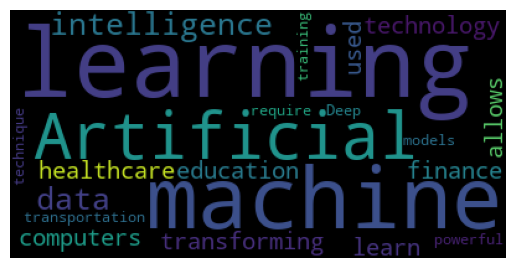

In [40]:
text = """
Artificial intelligence and machine learning are transforming technology.
Machine learning allows computers to learn from data.
Artificial intelligence is used in healthcare, finance, education and transportation.
Deep learning is a powerful technique in machine learning.
Machine learning models require data for training.
"""

wordcloud = WordCloud().generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

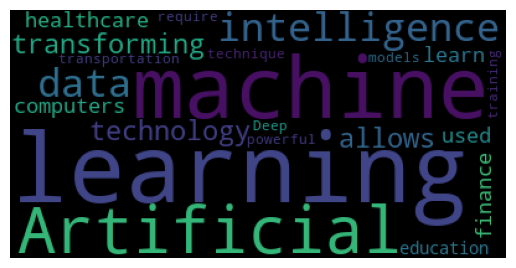

In [41]:
text = """
Artificial intelligence and machine learning are transforming technology.
Machine learning allows computers to learn from data.
Artificial intelligence is used in healthcare, finance, education and transportation.
Deep learning is a powerful technique in machine learning.
Machine learning models require data for training.
"""
wordcloud = WordCloud(stopwords=stop_words).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

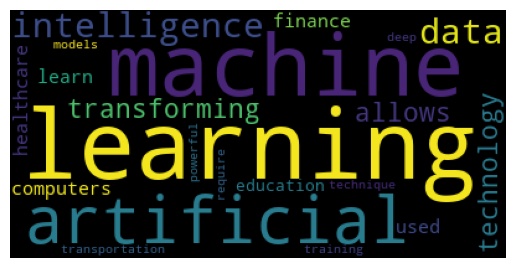

In [42]:
text = """
Artificial intelligence and machine learning are transforming technology.
Machine learning allows computers to learn from data.
Artificial intelligence is used in healthcare, finance, education and transportation.
Deep learning is a powerful technique in machine learning.
Machine learning models require data for training.
"""
text = text.lower()

wordcloud = WordCloud(stopwords=stop_words).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [43]:
from collections import Counter

text = """
Artificial intelligence and machine learning are transforming technology.
Machine learning allows computers to learn from data.
Artificial intelligence is used in healthcare, finance, education and transportation.
Deep learning is a powerful technique in machine learning.
Machine learning models require data for training.
"""
text = text.lower()

tokens = word_tokenize(text)

filtered_tokens = []

for word in tokens:
    if word.isalpha() and word not in stop_words:
        filtered_tokens.append(word)

frequency = Counter(filtered_tokens)

print(frequency)

Counter({'learning': 5, 'machine': 4, 'artificial': 2, 'intelligence': 2, 'data': 2, 'transforming': 1, 'technology': 1, 'allows': 1, 'computers': 1, 'learn': 1, 'used': 1, 'healthcare': 1, 'finance': 1, 'education': 1, 'transportation': 1, 'deep': 1, 'powerful': 1, 'technique': 1, 'models': 1, 'require': 1, 'training': 1})


In [44]:
print(frequency.most_common())

[('learning', 5), ('machine', 4), ('artificial', 2), ('intelligence', 2), ('data', 2), ('transforming', 1), ('technology', 1), ('allows', 1), ('computers', 1), ('learn', 1), ('used', 1), ('healthcare', 1), ('finance', 1), ('education', 1), ('transportation', 1), ('deep', 1), ('powerful', 1), ('technique', 1), ('models', 1), ('require', 1), ('training', 1)]


In [45]:
print(frequency.most_common(5))

[('learning', 5), ('machine', 4), ('artificial', 2), ('intelligence', 2), ('data', 2)]


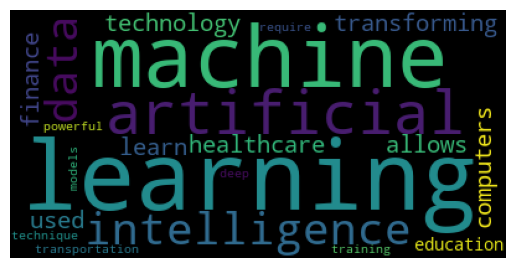

In [46]:
wordcloud = WordCloud().generate_from_frequencies(frequency)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

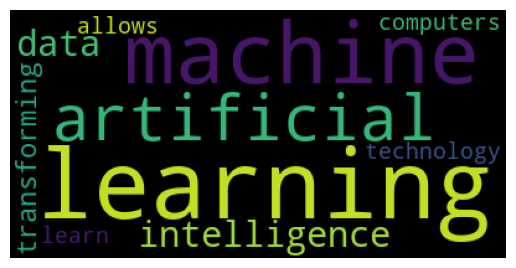

In [47]:
most_common = dict(frequency.most_common(10))
wordcloud = WordCloud().generate_from_frequencies(most_common)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

#Encoding - represent -> text numerically

"I like machine learning" -> [4,3,2,1]
"Machine learning is useful" -> [2,1,5,6]
"I like deep learning"

learning - 3 (1)
machine - 2 (2) 
like - 2 (3)
I - 2 (4)
is - 1 (5)
useful - 1 (6)
deep - 1 (7)

build a frequency vocabulary
sort the words acc to frequencies
lower integer index to higher frquencies

#why do we use frequency? 
#when you have too many words and you keep only few? 
#Integer encoding is also called indexing
#what happens a word is not in the vocabulary
#0 is reserved for padding


RAW TEXT -> TOKENIZATION  -> STOP WORDS -> STEMMING/LEMMATIZATION
-> POS TAGGING -> INTEGER ENCODING -> PADDING -> ONE HOT ENCODING/EMBEDDINGS

In [ ]:
sentences = [
    "The barber is a good person.",
    "The barber is a huge person.",
    "The barber knew the secret.",
    "The secret was kept by the barber.",
    "The barber kept the secret.",
    "The barber is driving a car."
]
processed = []

for sentence in sentences:
    words = word_tokenize(sentence.lower())
    tokens = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
        and word.isalpha()
    ]
    processed.append(tokens)

print(processed)

words = [
    word for sentence in processed for word in sentence
]

words

[['barber', 'good', 'person'], ['barber', 'huge', 'person'], ['barber', 'knew', 'secret'], ['secret', 'kept', 'barber'], ['barber', 'kept', 'secret'], ['barber', 'driving', 'car']]


In [75]:
words = [
    word for sentence in processed for word in sentence
]

words

['barber',
 'good',
 'person',
 'barber',
 'huge',
 'person',
 'barber',
 'knew',
 'secret',
 'secret',
 'kept',
 'barber',
 'barber',
 'kept',
 'secret',
 'barber',
 'driving',
 'car']

In [76]:
words = []

for sentence in processed:
    for word in sentence:
        words.append(word)

words

['barber',
 'good',
 'person',
 'barber',
 'huge',
 'person',
 'barber',
 'knew',
 'secret',
 'secret',
 'kept',
 'barber',
 'barber',
 'kept',
 'secret',
 'barber',
 'driving',
 'car']

In [77]:
#count frequencies manually, no hstack no counter

vocab = {}

for word in words:
    if word not in vocab:
        vocab[word]=0
    vocab[word] += 1

print(vocab)

{'barber': 6, 'good': 1, 'person': 2, 'huge': 1, 'knew': 1, 'secret': 3, 'kept': 2, 'driving': 1, 'car': 1}


In [78]:
#count frequencies manually, no hstack no counter

vocab = {}

for word in words:
    vocab[word] = vocab.get(word, 0) + 1
print(vocab)
print(vocab["barber"])

{'barber': 6, 'good': 1, 'person': 2, 'huge': 1, 'knew': 1, 'secret': 3, 'kept': 2, 'driving': 1, 'car': 1}
6


In [79]:
vocab = sorted(
    vocab.items(),
    key=lambda item: item[1],
    reverse=True
)

print(vocab)

[('barber', 6), ('secret', 3), ('person', 2), ('kept', 2), ('good', 1), ('huge', 1), ('knew', 1), ('driving', 1), ('car', 1)]


In [80]:
word_to_index = {}

for index, (word, frequency) in enumerate(vocab, start = 1):
    word_to_index[word] = index

word_to_index

{'barber': 1,
 'secret': 2,
 'person': 3,
 'kept': 4,
 'good': 5,
 'huge': 6,
 'knew': 7,
 'driving': 8,
 'car': 9}

In [81]:
vocab_size=5

top_words = vocab[:vocab_size]

top_words

[('barber', 6), ('secret', 3), ('person', 2), ('kept', 2), ('good', 1)]

In [82]:
word_to_index = {}

for index, (word, frequency) in enumerate(top_words, start = 1):
    word_to_index[word] = index

word_to_index

{'barber': 1, 'secret': 2, 'person': 3, 'kept': 4, 'good': 5}

In [83]:
# OOV - out of vocabulary

oov_index = len(word_to_index) + 1

word_to_index["<OOV>"] = oov_index

word_to_index

{'barber': 1, 'secret': 2, 'person': 3, 'kept': 4, 'good': 5, '<OOV>': 6}

In [84]:
#ENCODING

def encode(sentence, word_to_index):
    return [
        word_to_index.get(word,word_to_index["<OOV>"])
        for word in sentence
    ]


['barber', 'good', 'person'], 
1, 5, 3
['barber', 'huge', 'person']
1, 6, 3
['barber', 'knew', 'secret']
1, 6, 2
['secret', 'kept', 'barber']
2, 4, 1
['barber', 'kept', 'secret']
1, 4, 2
['barber', 'driving', 'car']
1, 6, 6

{'barber': 1, 'secret': 2, 'person': 3, 'kept': 4, 'good': 5, '<OOV>': 6}


In [86]:
encoded = []
for sentence in processed:
    encoded.append(encode(sentence,word_to_index))

encoded

[[1, 5, 3], [1, 6, 3], [1, 6, 2], [2, 4, 1], [1, 4, 2], [1, 6, 6]]

In [ ]:
#Auto frequencies -> Counter
from collections import Counter

In [ ]:
sentences = [
    "The barber is a good person.",
    "The barber is a huge person.",
    "The barber knew the secret.",
    "The secret was kept by the barber.",
    "The barber kept the secret.",
    "The barber is driving a car."
]
processed = []

for sentence in sentences:
    words = word_tokenize(sentence.lower())
    tokens = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
        and word.isalpha()
    ]
    processed.append(tokens)

words = [
    word for sentence in processed for word in sentence
] #flattening the words

In [88]:
word_counts= Counter(words)

word_counts

Counter({'barber': 6,
         'secret': 3,
         'person': 2,
         'kept': 2,
         'good': 1,
         'huge': 1,
         'knew': 1,
         'driving': 1,
         'car': 1})

In [89]:
word_counts['cat']

0

In [90]:
vocab_size = 5 
top_words = word_counts.most_common(vocab_size)

top_words

[('barber', 6), ('secret', 3), ('person', 2), ('kept', 2), ('good', 1)]

In [92]:
word_to_index2 = {
    word: index
    for index, (word, top_words)
    in enumerate(top_words, start=1)
}

print(word_to_index)

{'barber': 1, 'secret': 2, 'person': 3, 'kept': 4, 'good': 5}


In [93]:
# OOV - out of vocabulary

oov_index = len(word_to_index) + 1

word_to_index2["<OOV>"] = oov_index

word_to_index2

encoded = []
for sentence in processed:
    encoded.append(encode(sentence,word_to_index2))

encoded

[[1, 5, 3], [1, 6, 3], [1, 6, 2], [2, 4, 1], [1, 4, 2], [1, 6, 6]]

In [94]:
sentences = [
    "The barber is a good person.",
    "The barber is a huge person.",
    "The barber knew the secret.",
    "The secret was kept by the barber.",
    "The barber kept the secret.",
    "The barber is driving a car."
]
processed = []

for sentence in sentences:
    words = word_tokenize(sentence.lower())
    tokens = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
        and word.isalpha()
    ]
    processed.append(tokens)

In [95]:
import numpy as np

words = np.hstack(processed)

words

array(['barber', 'good', 'person', 'barber', 'huge', 'person', 'barber',
       'knew', 'secret', 'secret', 'kept', 'barber', 'barber', 'kept',
       'secret', 'barber', 'driving', 'car'], dtype='<U7')

In [96]:
from nltk import FreqDist

vocab = FreqDist(words)

vocab

FreqDist({np.str_('barber'): 6, np.str_('secret'): 3, np.str_('person'): 2, np.str_('kept'): 2, np.str_('good'): 1, np.str_('huge'): 1, np.str_('knew'): 1, np.str_('driving'): 1, np.str_('car'): 1})

In [97]:
# Keep top 5
vocab_size = 5
top_words = vocab.most_common(vocab_size)

# Assign integer indices
word_to_index3 = {
    word: index
    for index, (word, top_words)
    in enumerate(top_words, start=1)
}

print(word_to_index3)

{np.str_('barber'): 1, np.str_('secret'): 2, np.str_('person'): 3, np.str_('kept'): 4, np.str_('good'): 5}


In [98]:
# OOV - out of vocabulary

oov_index = len(word_to_index) + 1

word_to_index3["<OOV>"] = oov_index

word_to_index3

encoded = []
for sentence in processed:
    encoded.append(encode(sentence,word_to_index3))

encoded

[[1, 5, 3], [1, 6, 3], [1, 6, 2], [2, 4, 1], [1, 4, 2], [1, 6, 6]]

In [138]:
sentences = [
    "The barber is a good person.",
    "The barber is a huge person.",
    "The barber knew the secret.",
    "The secret was kept by the barber.",
    "The barber kept the secret.",
    "The barber is driving a car."
]
processed = []

for sentence in sentences:
    words = word_tokenize(sentence.lower())
    tokens = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
        and word.isalpha()
    ]
    processed.append(tokens)

processed

[['barber', 'good', 'person'],
 ['barber', 'huge', 'person'],
 ['barber', 'knew', 'secret'],
 ['secret', 'kept', 'barber'],
 ['barber', 'kept', 'secret'],
 ['barber', 'driving', 'car']]

In [139]:
from tensorflow.keras.preprocessing.text import Tokenizer
#text -> token -> clean -> freq -> vocab -> integer -> encoding

Tokenizer is a Keras utility used to build a vocabulary from text and convert words into integer IDs.
fit_on_texts() 
    learns from the corpus
word_counts 
    frequencies in OrderedDict 
word_index 
    integer ID assigned to each word
texts_to_sequences()
    encodes the text into integer sequences

-> which words exists?
-> frequency of words
-> integer index assigned to each word

In [148]:
#text -> token 
tokenizer = Tokenizer(num_words=10,oov_token = "<OOV>")
tokenizer.fit_on_texts(processed)

In [149]:
#freq -> vocab
print(tokenizer.word_counts)

OrderedDict({'barber': 6, 'good': 1, 'person': 1, 'cut': 1, 'hair': 1, 'well': 1, 'vip': 1, 'knew': 1, 'promise': 1, 'secret': 2, 'kept': 2, 'till': 1, 'end': 1, 'days': 1, 'weeks': 1, 'driving': 1, 'bike': 1, 'work': 1})


In [150]:
#integer -> encoding
print(tokenizer.word_index)

{'<OOV>': 1, 'barber': 2, 'secret': 3, 'kept': 4, 'good': 5, 'person': 6, 'cut': 7, 'hair': 8, 'well': 9, 'vip': 10, 'knew': 11, 'promise': 12, 'till': 13, 'end': 14, 'days': 15, 'weeks': 16, 'driving': 17, 'bike': 18, 'work': 19}


In [151]:
#encoding
sequences = tokenizer.texts_to_sequences(processed)

sequences

[[2, 5, 6, 7, 8, 9],
 [2, 1],
 [2, 1, 1],
 [3, 4, 2, 1, 1],
 [2, 4, 3, 1, 1],
 [2, 1, 1, 1]]

In [152]:
for sentence,sequence in zip(processed,sequences):
    print(sentence)
    print("->", sequence, "\n")

['barber', 'good', 'person', 'cut', 'hair', 'well']
-> [2, 5, 6, 7, 8, 9] 

['barber', 'vip']
-> [2, 1] 

['barber', 'knew', 'promise']
-> [2, 1, 1] 

['secret', 'kept', 'barber', 'till', 'end']
-> [3, 4, 2, 1, 1] 

['barber', 'kept', 'secret', 'days', 'weeks']
-> [2, 4, 3, 1, 1] 

['barber', 'driving', 'bike', 'work']
-> [2, 1, 1, 1] 



In [154]:
sentences = [
    "The barber is a good person.",
    "The barber is a sweet person.",
    "The barber knew the promise.",
    "The secret was kept by the barber.",
    "The barber kept the secret.",
    "The barber is driving a bike."
]

processed = []

for sentence in sentences:
    words = word_tokenize(sentence.lower())
    tokens = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
        and word.isalpha()
    ]
    processed.append(tokens)

#encoding
sequences = tokenizer.texts_to_sequences(processed)

for sentence,sequence in zip(processed,sequences):
    print(sentence)
    print("->", sequence, "\n")

['barber', 'good', 'person']
-> [2, 5, 6] 

['barber', 'sweet', 'person']
-> [2, 1, 6] 

['barber', 'knew', 'promise']
-> [2, 1, 1] 

['secret', 'kept', 'barber']
-> [3, 4, 2] 

['barber', 'kept', 'secret']
-> [2, 4, 3] 

['barber', 'driving', 'bike']
-> [2, 1, 1] 



In [164]:
sentences = [
    "The barber is a good person and he cut my hair well",
    "The barber is VIP",
    "The barber knew the promise",
    "The secret was kept by the barber till the end",
    "The barber kept the secret for days and weeks.",
    "The barber is driving a bike to work ."
]

processed = []

for sentence in sentences:
    words = word_tokenize(sentence.lower())
    tokens = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
        and word.isalpha()
    ]
    processed.append(tokens)

#encoding
sequences = tokenizer.texts_to_sequences(processed)

sequences

[[2, 5, 6, 7, 8, 9],
 [2, 1],
 [2, 1, 1],
 [3, 4, 2, 1, 1],
 [2, 4, 3, 1, 1],
 [2, 1, 1, 1]]

In [161]:
#find the max sequence length

max_len = max(len(item) for item in sequences)
max_len

6

In [ ]:
padded = sequences

for item in padded:
    while len(item) < max_len:
        item.append(0)

padded

[[2, 5, 6, 7, 8, 9],
 [2, 1, 0, 0, 0, 0],
 [2, 1, 1, 0, 0, 0],
 [3, 4, 2, 1, 1, 0],
 [2, 4, 3, 1, 1, 0],
 [2, 1, 1, 1, 0, 0]]

In [166]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded = pad_sequences(sequences)

padded

array([[2, 5, 6, 7, 8, 9],
       [0, 0, 0, 0, 2, 1],
       [0, 0, 0, 2, 1, 1],
       [0, 3, 4, 2, 1, 1],
       [0, 2, 4, 3, 1, 1],
       [0, 0, 2, 1, 1, 1]], dtype=int32)

In [168]:
padded = pad_sequences(sequences,padding='post')

padded

array([[2, 5, 6, 7, 8, 9],
       [2, 1, 0, 0, 0, 0],
       [2, 1, 1, 0, 0, 0],
       [3, 4, 2, 1, 1, 0],
       [2, 4, 3, 1, 1, 0],
       [2, 1, 1, 1, 0, 0]], dtype=int32)

In [179]:
for sentence in sequences:
    one_hot = to_categorical(sentence)
    print(one_hot)

[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0. 0. 1.]
 [0. 1. 0.]]
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


#One Hot Encoding
I love NLP Python
1  2   3    4 

I       [1 0 0 0]
love    [0 1 0 0]
NLP     [0 0 1 0]
Python  [0 0 0 1]

In [169]:
from tensorflow.keras.utils import to_categorical

In [176]:
sentence = "The barber is a good person and he kept my secret"

encoded = tokenizer.texts_to_sequences([sentence])

encoded

[[1, 2, 1, 1, 5, 6, 1, 1, 4, 1, 3]]

In [177]:
one_hot = to_categorical(encoded)

one_hot

array([[[0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.]]])